# Table of Contents

* [1.1 Introduction](#1.1-Introduction)
* [1.2 Preparation](#1.2-Preparation)
    * [1.2.1 Import the dataset](#1.2.1-Import-the-dataset)
* [1.3 Dataset Summary ](#1.3-Dataset-Summary)
* [1.4 Missing Values and Duplicates analysis](#1.4-Missing-Values-and-Duplicates-analysis)
    * [1.4.1 Missing Values](#1.4.1-Missing-Values)
    * [1.4.2 Duplicates](#1.4.2-Duplicates)
* [1.5 Univariate Analysis](#1.5-Univariate-Analysis)
    * [1.5.1 Numerical Variables](#1.5.1-Numerical-Variables)
    * [1.5.2 Categorical Variables](#1.5.3-Categorical-Variables)
* [1.6 Feature Engeering](#1.7-Final-Insights) 
* [1.7 Bivariate Analysis](#1.6-Bivariate-Analysis)
    * [1.7.1 Correlation Matrix](#1.6.1-Correlation-Matrix)
* [1.8 Final Insights](#1.7-Final-Insights)

# 1.1 Introduction

This notebook performs an Exploratory Data Analysis (EDA) on the `customer_info.csv` dataset. We focus on data quality (missing values, duplicates, outliers) and feature engineering to prepare the data for predictive modeling.

In this notebook we also perform feature engineering and correct some datatypes. Preprocessing will be implemented later as a separate function.

# 1.2 Preparation

Loading necessary libraries and setting plot styles.

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from datetime import datetime
from shapely.geometry import Point, box, Polygon, LineString
import math


## 1.2.1 Import the dataset

In [5]:
data = pd.read_csv('customer_info.csv')

# 1.3 Dataset Summary

### 1.3.1 Initial Dataset Preview

We preview the first few rows of the dataset using `data.head()` to inspect the column headers, the layout of the values, and the general structure of the loaded data.


In [6]:
data.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


### 1.3.2 Index Configuration

Since `customer_id` is a unique identifier, we set it as the index of the DataFrame. This prevents it from being treated as a numerical feature in statistical calculations and models.


In [7]:
data.set_index('customer_id', drop=True, inplace=True)
data.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


### 1.3.3 Dataset Structure and Feature Datatypes

Using `data.info()`, we check the structural summary of the DataFrame:
* **Total Entries:** 33,038 customer records (indexed from 3 to 40,000).
* **Data Types:** 21 numeric columns (`float64`) and 3 object columns (`customer_name`, `customer_gender`, `customer_birthdate`).
* **Null Values:** Presence of missing values in columns like `kids_home` (32,708 non-null). `loyalty_card_number` stands out with only 19,932 non-null entries, indicating that a significant portion of customers do not have a loyalty card.


In [8]:
print("\nDataset Info:")
data.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables           

### 1.3.4 Statistical Descriptive Summary

Transposing `data.describe()` provides standard descriptive statistics for the numerical variables:
* **Spending Variables:** Large standard deviations relative to the means (e.g., grocery spend ranges from 0 to 104,670) reveal highly diverse purchasing power and behavior.
* **Integrity Issues & Anomalies:**
  * **Negative Percentages:** The minimum value for `percentage_of_products_bought_promotion` is `-1.27`, which is mathematically incorrect for a percentage/ratio.
  * **Future Dates:** The maximum year under `year_first_transaction` is `2029`, representing future transactional dates that will need correction.
  * **Constant Value:** `loyalty_card_number` has a mean of `1.0` and standard deviation of `0.0`, suggesting that all non-null values are exactly `1.0`.


In [9]:
print("\nNumerical Description:")
data.describe().T


Numerical Description:


,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


# 1.4 Missing Values and Duplicates analysis

## 1.4.1 Missing Values

In [10]:
null_counts = data.isnull().sum()
missing_df = pd.DataFrame({
    'Missing Values': null_counts
}).sort_values(by='Missing Values', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] >= 0])

Missing Values Summary:
                                         Missing Values
loyalty_card_number                               13106
lifetime_spend_fish                                 991
typical_hour                                        661
lifetime_spend_electronics                          661
lifetime_spend_videogames                           661
lifetime_spend_meat                                 661
lifetime_spend_vegetables                           661
lifetime_spend_petfood                              661
number_complaints                                   661
percentage_of_products_bought_promotion             330
distinct_stores_visited                             330
teens_home                                          330
kids_home                                           330
lifetime_spend_hygiene                              330
lifetime_spend_alcohol_drinks                       330
customer_birthdate                                  165
latitude                

Most features have a manageable number of missing values — around 330 to 991 rows — likely corresponding to the same subset of customers with incomplete records, suggesting the missingness is structural rather than random. 

The clear outlier is `loyalty_card_number` with **13,106 missing values**. This is almost certainly not random — it simply means those customers do not have a loyalty card, so its absence is meaningful in itself. Imputing this column would make no sense, and since it is a pure identifier with no behavioural signal, it will be dropped entirely in preprocessing

## 1.4.2 Duplicates

This section verifies whether the dataset contains repeated entries.
Since `customer_id` was set as the index in section 1.3, standard `data.duplicated()` does not include it. We use:
- `data.reset_index().duplicated().sum()` to check for full row duplicates **with** the index column included.
- `data.index.duplicated().sum()` to verify if the unique identifier `customer_id` contains any duplicate values.

A duplicate customer ID is important because `customer_id` should uniquely identify each customer. If the same ID repeats, the dataset may contain:
- exact duplicate records, or
- conflicting information for the same customer.

In [11]:
print(f"Full row duplicates (including customer_id): {data.reset_index().duplicated().sum()}")
print(f"Duplicate customer IDs: {data.index.duplicated().sum()}")

Full row duplicates (including customer_id): 0
Duplicate customer IDs: 0


# 1.5 Univariate Analysis

## 1.5.1 Numerical Variables

Here we are selecting the numerical variables for  some analysis, even thought the *id* feature is considered a numerical variable we´re not considering it for the future analysis because there is no pattern or relevant information for our future model since it's only an identification of our records

In [12]:
numeric_cols = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_spend_groceries",
    "lifetime_spend_electronics",
    "typical_hour",
    "lifetime_spend_vegetables",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_hygiene",
    "lifetime_spend_videogames",
    "lifetime_spend_petfood",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "year_first_transaction",
    "loyalty_card_number",
    "latitude",
    "longitude"
]

In [13]:
num_cols = data.drop(columns=['customer_name','customer_gender','customer_birthdate'])

### Constant Variables

In [14]:
num_cols.var()

kids_home                                  1.322927e+00
teens_home                                 9.272217e-01
number_complaints                          8.004128e-01
distinct_stores_visited                    2.802657e+00
lifetime_spend_groceries                   1.436619e+08
lifetime_spend_electronics                 1.192453e+07
typical_hour                               2.356819e+01
lifetime_spend_vegetables                  4.285445e+05
lifetime_spend_nonalcohol_drinks           7.604798e+04
lifetime_spend_alcohol_drinks              2.680592e+05
lifetime_spend_meat                        2.333110e+05
lifetime_spend_fish                        2.470775e+05
lifetime_spend_hygiene                     3.700500e+05
lifetime_spend_videogames                  2.123201e+05
lifetime_spend_petfood                     2.567525e+04
lifetime_total_distinct_products           1.121966e+04
percentage_of_products_bought_promotion    8.045041e-02
year_first_transaction                     2.532

Checking for constant variables — features with zero variance that carry no information for clustering — only `loyalty_card_number` has a variance of exactly **0.0**, confirming it is a constant and will be dropped in preprocessing.

All other features show non-zero variance. Notably, `latitude` and `longitude` have extremely low variance (~5e-04 and ~8e-04 respectively).While not technically constant, their near-zero variance makes them unlikely to contribute meaningful separation in clustering, so they will likely be dropped as well.

### Distribution of each feature 
Histograms help visualize how each numeric variable is distributed, showing skewness, central tendency, and spread.

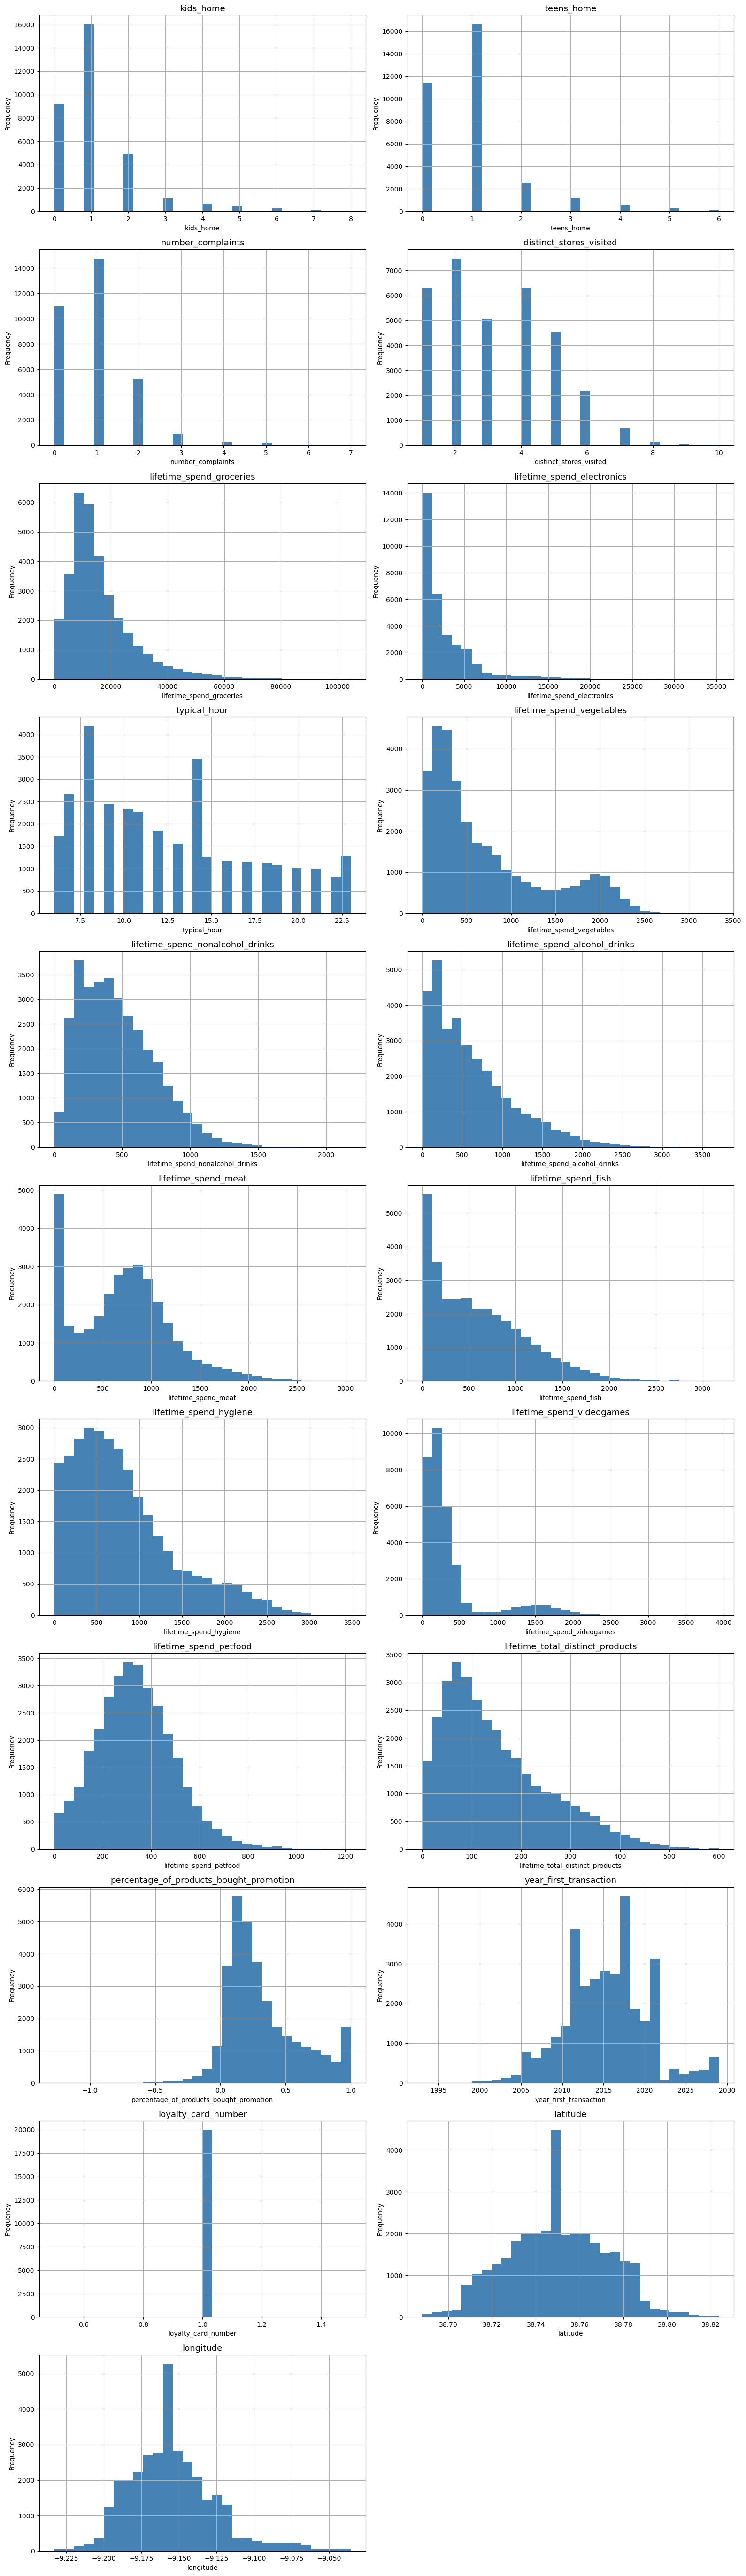

In [15]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data[col].hist(bins=30, color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Esconder eixos vazios se o número de colunas for ímpar
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusions about the Numerical Data Distribution

After analyzing the histograms above, several insights can be drawn regarding the distribution of the numerical features.

### The Shape of the Distributions

We can characterize the overall shape of each variable based on its histogram:

- **Right-Skewed Variables (log transformation candidates):** `lifetime_spend_groceries`, `lifetime_spend_electronics`, `lifetime_spend_vegetables`, `lifetime_spend_nonalcohol_drinks`, `lifetime_spend_alcohol_drinks`, `lifetime_spend_meat`, `lifetime_spend_fish`, `lifetime_spend_hygiene`, `lifetime_spend_petfood`, `lifetime_total_distinct_products` and `lifetime_spend_videogames` have most observations concentrated near zero, with a long right tail representing a few high spenders. We will apply log transformation to these features in the preprocessing phase to make their distributions more normal.

- **Approximately Normal (no action needed):** `lifetime_spend_petfood` show a roughly symmetric, bell-shaped distribution, indicating consistent spending behaviour across customers.

- **Uniform-like:** `distinct_stores_visited` is relatively spread across its range with no dominant peak, suggesting customers visit a varied number of stores without a clear pattern.

- **Discrete / Sparse:** `kids_home`, `teens_home` and `number_complaints` are heavily concentrated at 0 and 1 with very few higher values. These are low-variance features and their usefulness for clustering should be evaluated.

### Other Notes

`typical_hour` shows a bimodal pattern with peaks around 8–9am and 15pm, which could be meaningful for segmentation. `year_first_transaction` has visible spikes that likely reflect onboarding campaigns or data collection changes over the years. `percentage_of_products_bought_promotion` presents negative values, which is worth investigating before preprocessing. Finally, `loyalty_card_number` will be dropped as it is a pure identifier with no distributional value.


### Whiskers and Outliers

This section uses boxplots to visually identify outliers and compare the spread of numerical variables.

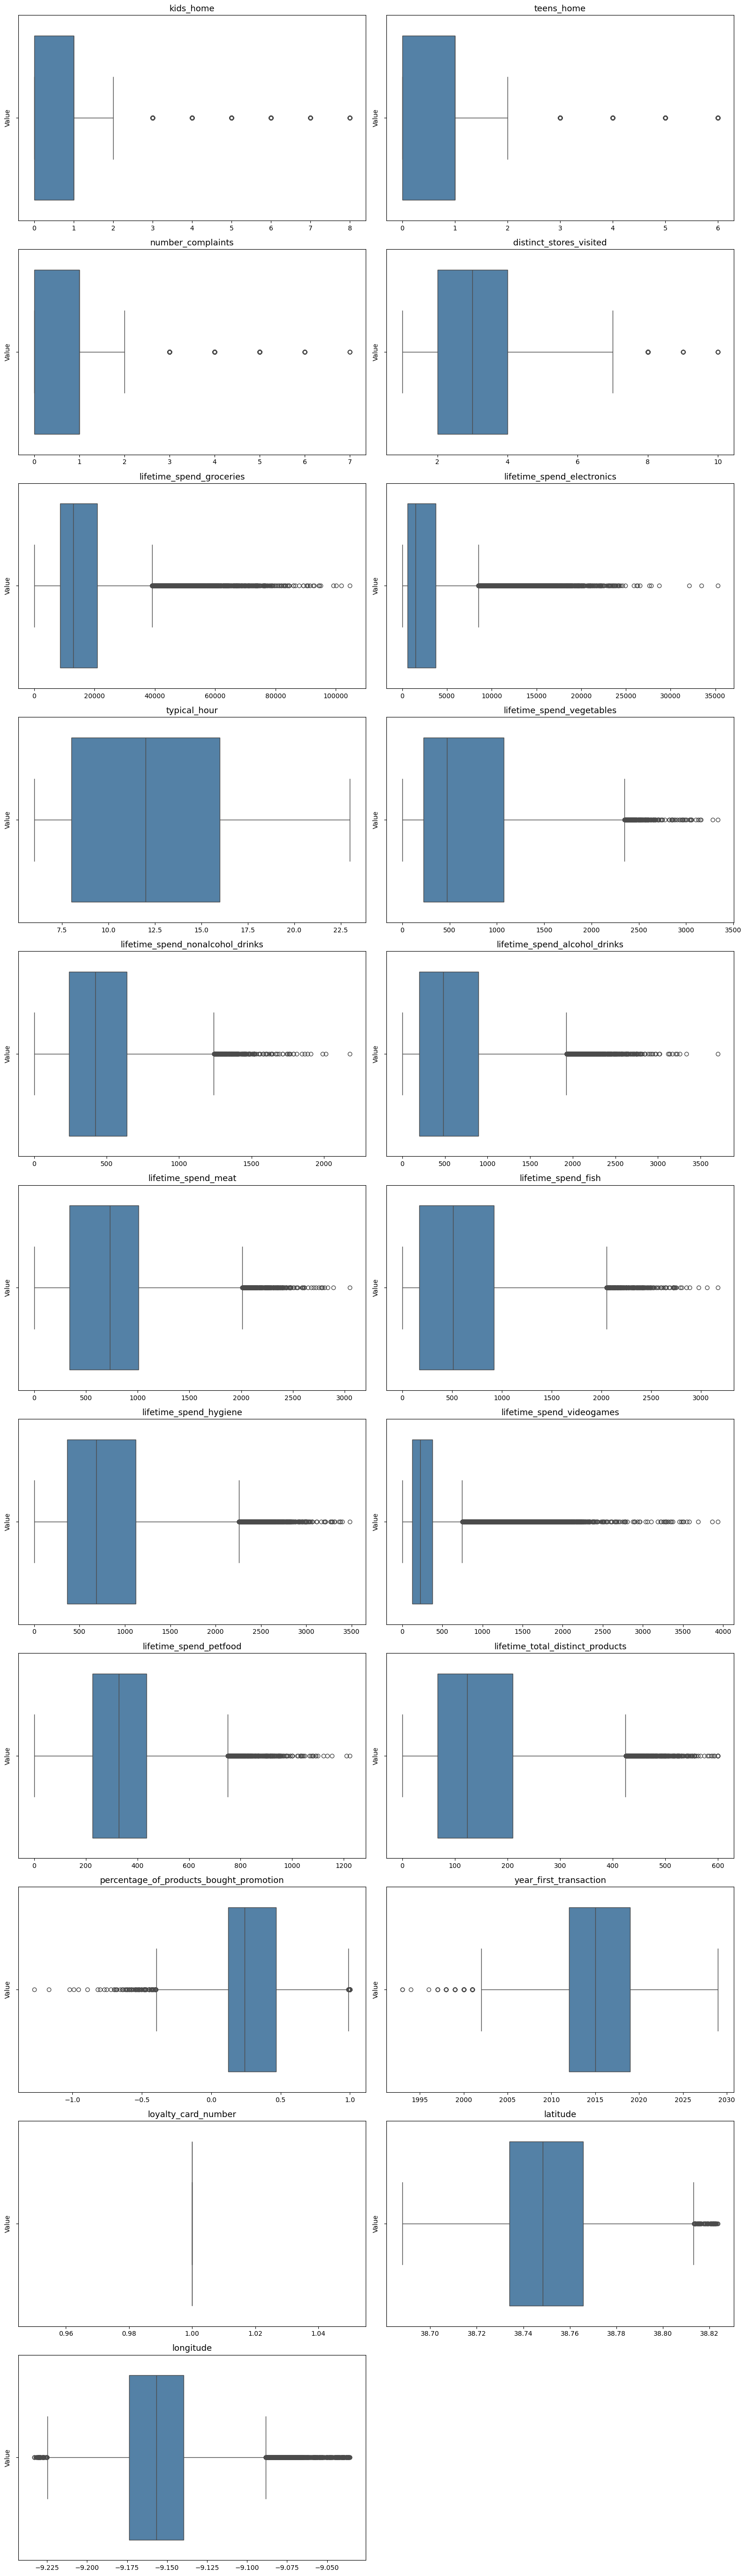

In [16]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=data[col], color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Conclusions about the Outliers

After analyzing the boxplots above, several insights can be drawn regarding the presence and severity of outliers across features.

### Outlier Severity

We can characterize each variable by its outlier behaviour:

- **Heavy outliers (require treatment):** `lifetime_spend_groceries`, `lifetime_spend_electronics`, `lifetime_spend_nonalcohol_drinks`, `lifetime_spend_alcohol_drinks`, `lifetime_spend_meat`, `lifetime_spend_fish`, `lifetime_spend_hygiene`, `lifetime_spend_videogames`, `lifetime_spend_petfood` and `lifetime_total_distinct_products` all show a dense cloud of outliers stretching far into the right tail. These are consistent with the right-skewed distributions observed in the histograms, and confirm that log transformation followed by outlier capping will be necessary in preprocessing.

- **Moderate outliers (worth monitoring):** `kids_home`, `teens_home`, `number_complaints` and `lifetime_spend_vegetables` show a small number of isolated outlier points beyond the whiskers. Given that these are discrete or low-variance features, the outliers likely represent genuine edge cases rather than noise.

- **No meaningful outliers:** `distinct_stores_visited` and `typical_hour` show clean distributions with whiskers covering most of the range and very few points outside, suggesting no aggressive treatment is needed.

### Other Notes

`percentage_of_products_bought_promotion` shows outliers on the **left tail**, around -1.0, reinforcing the data quality concern raised in the histogram analysis — negative percentages are not interpretable and should be investigated. `year_first_transaction` has a few early outliers around 1995–2000, which likely correspond to the oldest customers in the dataset. `loyalty_card_number` shows no variance whatsoever in the boxplot, further confirming it should be dropped. `latitude` and `longitude` both present outlier clusters at the edges of their ranges, but given the overall tight geographic spread, these likely just reflect customers at the boundary of the Lisbon area.

### Percentage of products bought promotion

Since this feature represents the proportion of products purchased on promotion, valid values must lie within the range $[0, 1]$ (or $0\%$ to $100\%$). However, our initial statistical summary in section 1.3 highlighted the presence of negative values.

We analyze the extent of this anomaly in the code below:
- **Number of negative values:** 1,755 records
- **Percentage of dataset affected:** 5.31%

Because negative values are mathematically invalid for a proportion, we treat them by converting all negative instances to `NaN`. This ensures they will be handled correctly during the subsequent imputation phase.

In [17]:
neg_mask = data['percentage_of_products_bought_promotion'] < 0
print(f"Number of negative values: {neg_mask.sum()}")
print(f"Percentage of dataset: {(neg_mask.sum() / len(data) * 100):.2f}%")

Number of negative values: 1755
Percentage of dataset: 5.31%


In [18]:
data.loc[data['percentage_of_products_bought_promotion'] < 0, 'percentage_of_products_bought_promotion'] = np.nan

### 1.5.1.3 Typical Shopping Hour

We visualize the distribution of `typical_hour` using a frequency count plot. This feature represents the hour of the day (from 6:00 to 23:00) when a customer most frequently makes their transactions.

**Observations:**
- **Peak Hours:** The distribution has a clear structure showing peak shopping times.
- **Range:** Shopping activity is recorded between **6:00 AM** and **11:00 PM**, with a median shopping hour around **12:00 PM (noon)**.
- **Utility:** Understanding peak hours is crucial for target marketing, scheduling promotional offers, and load balancing across channels.

C:\Users\almad\AppData\Local\Temp\ipykernel_6996\3441925477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='typical_hour', data=data,palette= 'crest')


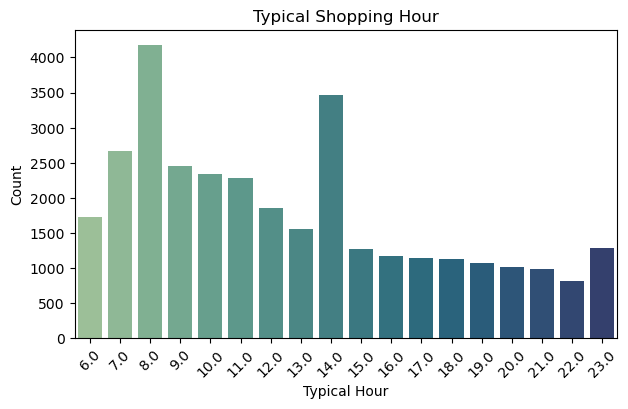

In [19]:
#Shopping hour
plt.figure(figsize=(7, 4))
sns.countplot(x='typical_hour', data=data,palette= 'crest')
plt.title('Typical Shopping Hour')
plt.xlabel('Typical Hour')
plt.ylabel('Count')

# Rotate x-axis labels
plt.xticks(rotation=45)  # Adjust the rotation angle as needed

plt.show()

### 1.5.1.4 Geographical Analysis

Using the spatial features `latitude` and `longitude`, we map the geographical distribution of our customer base:
1. **GeoDataFrame Conversion:** We convert the pandas DataFrame into a GeoPandas `GeoDataFrame`, mapping coordinate pairs into standard geometry `Point` objects under the **EPSG:4326** Coordinate Reference System (WGS 84).
2. **Interactive Mapping:** We use `.explore()` on a sample of the first 1,000 customers to plot their precise coordinates on an interactive map.

**Observations:**
- **Region:** The coordinate ranges (latitudes around `38.7` and longitudes around `-9.15`) show that our customer base is located in the **Lisbon Metropolitan Area, Portugal**.
- **Application:** Spatial clustering can help reveal regional purchasing habits and density of customer segments, which helps guide retail localization strategies.

In [20]:
customer_info_gd = gpd.GeoDataFrame(
    data, geometry=gpd.points_from_xy(data.longitude, data.latitude), crs="EPSG:4326")
customer_info_gd.drop(columns=['latitude', 'longitude'], inplace=True)
customer_info_gd.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,geometry
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,POINT (-9.2157 38.794)
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,POINT (-9.1796 38.752)
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,POINT (-9.1607 38.781)
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,POINT (-9.1487 38.74)
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,POINT (-9.1882 38.733)


In [21]:
customer_info_gd.iloc[0:1000].explore()

c:\Users\almad\anaconda3\envs\MachineLearning\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1.5.2 Categorical Variables

### 1.5.2.1 Customer Gender Distribution

We check the distribution of the `customer_gender` variable to understand the demographic balance in our dataset.

**Observations:**
- **Female Customers:** 16,577 (50.18%)
- **Male Customers:** 16,461 (49.82%)
- **Implication:** The customer base is almost perfectly split down the middle. This balance prevents gender bias in our clustering patterns and ensures that both gender groups have equal statistical representation in downstream models without any sampling correction needed.

In [22]:
data['customer_gender'].value_counts()

customer_gender
female    16577
male      16461
Name: count, dtype: int64

### Customer Birthdate

In this section we convert `customer_birthdate` to a datetime type and compute an `age` feature (in years). This `age` will be used for analysis and downstream modelling instead of separate birth month/day/year fields.

C:\Users\almad\AppData\Local\Temp\ipykernel_6996\725855880.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['customer_birthdate'] = pd.to_datetime(data['customer_birthdate'], errors='coerce')


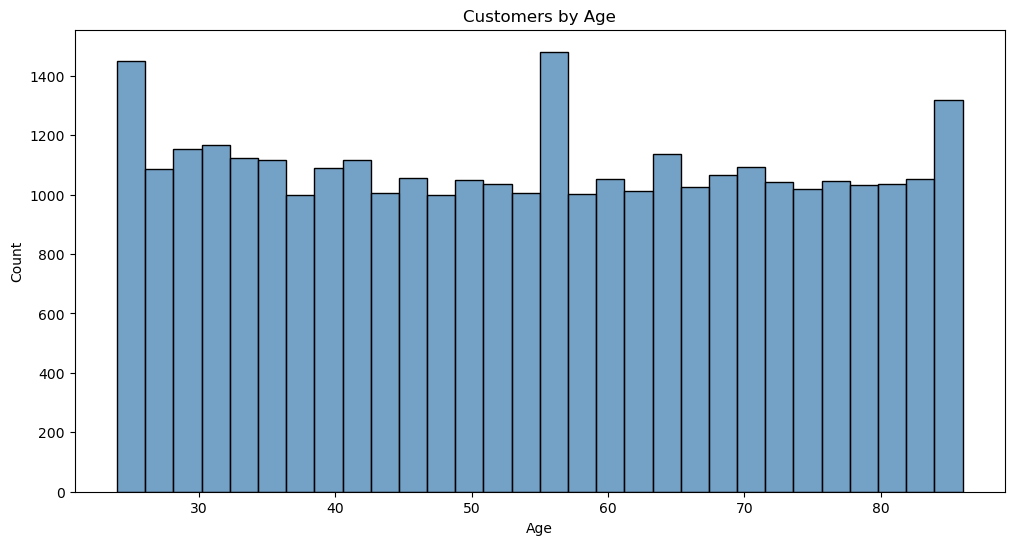

In [23]:
data['customer_birthdate'] = pd.to_datetime(data['customer_birthdate'], errors='coerce')
# Calculate age in years (approximate)
today = pd.Timestamp('today')
data['age'] = (today - data['customer_birthdate']).dt.days // 365
# Drop the original birthdate column; we only keep `age`
data.drop(columns=['customer_birthdate'], inplace=True)

plt.figure(figsize=(12, 6))
ax = sns.histplot(data=data, x='age', bins=30, color='steelblue')
ax.set_title('Customers by Age')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.show()

The distribution of customers by age is remarkably **uniform across the observed range**, indicating the dataset may have been **synthetically generated or balanced by age**. In real-world data, age distributions are rarely this evenly spread.


# 1.6 Feature Engineering

Feature engineering is a critical step to extract more descriptive patterns and prepare our tabular variables for clustering. We will transform raw attributes into features that capture relative customer behavior, family structure, and loyalty status.

### 1.6.1 Gender Binary Encoding
We convert the categorical variable `customer_gender` into a binary numeric feature `female` ($1 = \text{Female}$, $0 = \text{Male}$) to make it suitable for distance-based clustering algorithms.


In [24]:
# Map values in the 'customer_gender' column
data['female'] = data['customer_gender'].map({'male': 0, 'female': 1})
data.drop(columns=['customer_gender'], inplace=True)
data.head()

,customer_name,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude,age,female
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,...,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739,56.0,1
4,Bsc. Glenda Bauman,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,...,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611,50.0,1
5,Msc. Antonio Campbell,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,...,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656,54.0,0
7,John Kelling,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,...,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679,43.0,0
8,Arthur Dematteo,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,...,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188,56.0,0


### 1.6.2 Household Composition (Total Kids)
To simplify our models and reduce dimensionality, we merge `kids_home` and `teens_home` into a single feature: `total_kids`. This gives us a direct measure of the total number of children in the household.


In [25]:
data['total_kids'] = data['kids_home'] + data['teens_home']
data.drop(columns=['kids_home', 'teens_home'], inplace=True)

We visualize the family size distribution across the customer base:


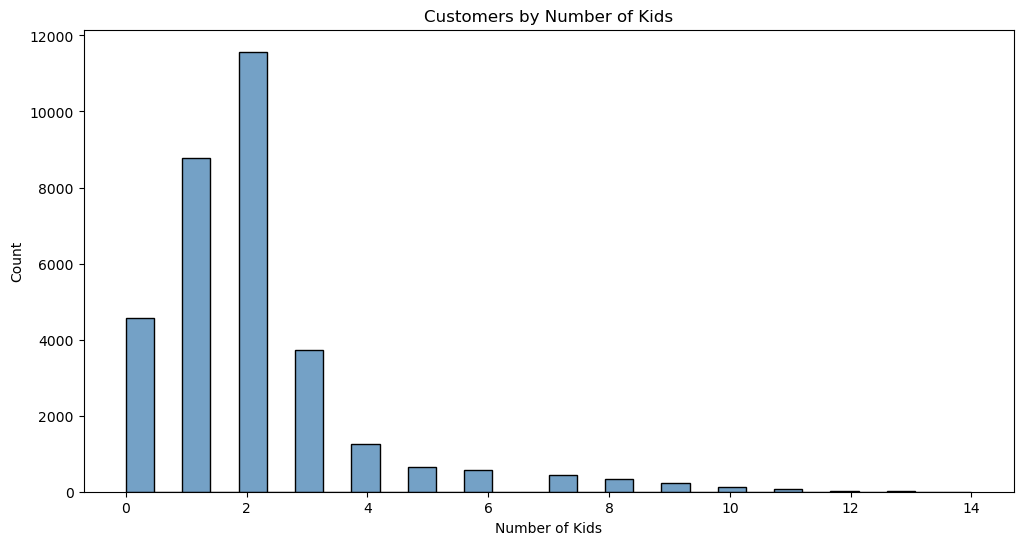

In [26]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=data, x='total_kids', bins=30, color='steelblue')
ax.set_title('Customers by Number of Kids')
ax.set_xlabel('Number of Kids')
ax.set_ylabel('Count')
plt.show()

### 1.6.3 Total Lifetime Spend
We sum all individual category spends (`groceries`, `electronics`, `vegetables`, `nonalcohol_drinks`, `alcohol_drinks`, `meat`, `fish`, `hygiene`, `videogames`, `petfood`) to compute `total_lifetime_spend`. This represents the overall cumulative monetary value of each customer.


In [27]:
spend_cols = [col for col in data.columns if 'lifetime_spend' in col]
data['total_lifetime_spend'] = data[spend_cols].sum(axis=1)

We plot the distribution of overall customer spending:


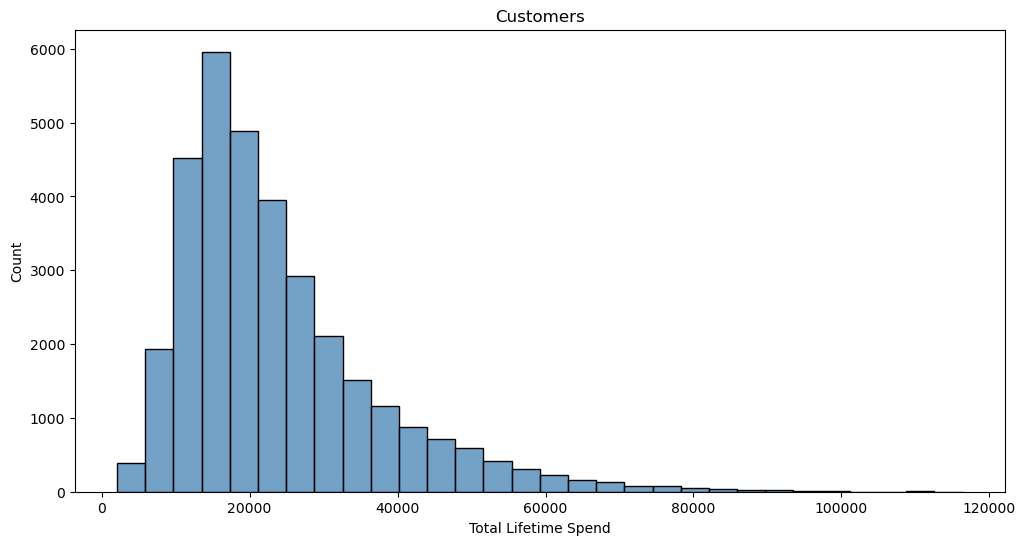

In [28]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(data=data, x='total_lifetime_spend', bins=30, color='steelblue')
ax.set_title('Customers')
ax.set_xlabel('Total Lifetime Spend')
ax.set_ylabel('Count')
plt.show()

### 1.6.4 Average Spend per Product
We construct `loyalty_product_type` by dividing `total_lifetime_spend` by the number of `lifetime_total_distinct_products`. This feature reflects the average unit price paid per product, indicating whether a customer is a budget shopper (buying bulk/low-cost items) or a premium consumer (buying high-margin/expensive items).


In [29]:
data['loyalty_product_type'] = (data['total_lifetime_spend'] / data['lifetime_total_distinct_products']).replace([np.inf, -np.inf], 0).fillna(0)

### 1.6.5 Loyalty Card Ownership
The original `loyalty_card_number` column has a massive amount of missing data (60% missing) because non-members do not have a card. We simplify this into a binary indicator `has_loyalty_card` ($1 = \text{Yes}$, $0 = \text{No}$) and drop the redundant numeric ID column.


In [30]:
data['has_loyalty_card'] = data['loyalty_card_number'].notna().astype(int)
data.drop(columns=['loyalty_card_number'], inplace=True)

We check the proportion of loyalty card members in our dataset:


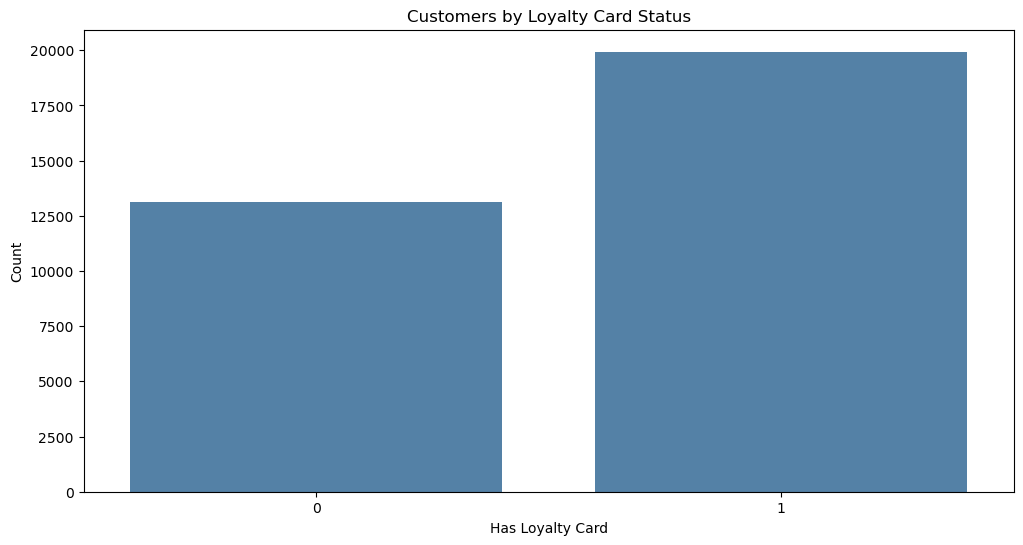

In [31]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=data, x='has_loyalty_card', color='steelblue')
ax.set_title('Customers by Loyalty Card Status')
ax.set_xlabel('Has Loyalty Card')
ax.set_ylabel('Count')
plt.show()

### 1.6.6 Relative Spending Proportions
Since absolute spending varies greatly depending on customer budgets, absolute spends can dominate clustering metrics. To capture the *consumption style* independent of total budget, we compute the percentage of total spend allocated to each product category (e.g. grocery spend / total spend).


In [32]:
# 1. Identificar todas as categorias de lifetime_spend
spend_cols = [col for col in data.columns if 'lifetime_spend' in col and 'total' not in col and 'prop' not in col]

# 2. Calcular o gasto total (caso não tenhas essa variável no dataset atual)
if 'total_lifetime_spend' not in data.columns:
    data['total_lifetime_spend'] = data[spend_cols].sum(axis=1)

# 3. Criar as proporções para cada categoria
for col in spend_cols:
    prop_col = col + '_prop'
    # Dividir pelo total (substituindo o 0 por NaN para não dar erro de divisão por zero)
    data[prop_col] = data[col] / data['total_lifetime_spend'].replace(0, np.nan)
    # Preencher com 0 os casos em que a divisão resultou em NaN
    data[prop_col] = data[prop_col].fillna(0)

# Verificar os resultados
cols_proporcao = [col for col in data.columns if '_prop' in col]
display(data[['total_lifetime_spend'] + cols_proporcao].head())


,total_lifetime_spend,lifetime_spend_groceries_prop,lifetime_spend_electronics_prop,lifetime_spend_vegetables_prop,lifetime_spend_nonalcohol_drinks_prop,lifetime_spend_alcohol_drinks_prop,lifetime_spend_meat_prop,lifetime_spend_fish_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop
customer_id,,,,,,,,,,,
3,18590.0,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
4,20233.0,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
5,15549.0,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
7,14952.0,0.501137,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
8,25797.0,0.356127,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095


We plot the distributions of these relative spending proportions to visualize how consumers distribute their wallet across product segments:


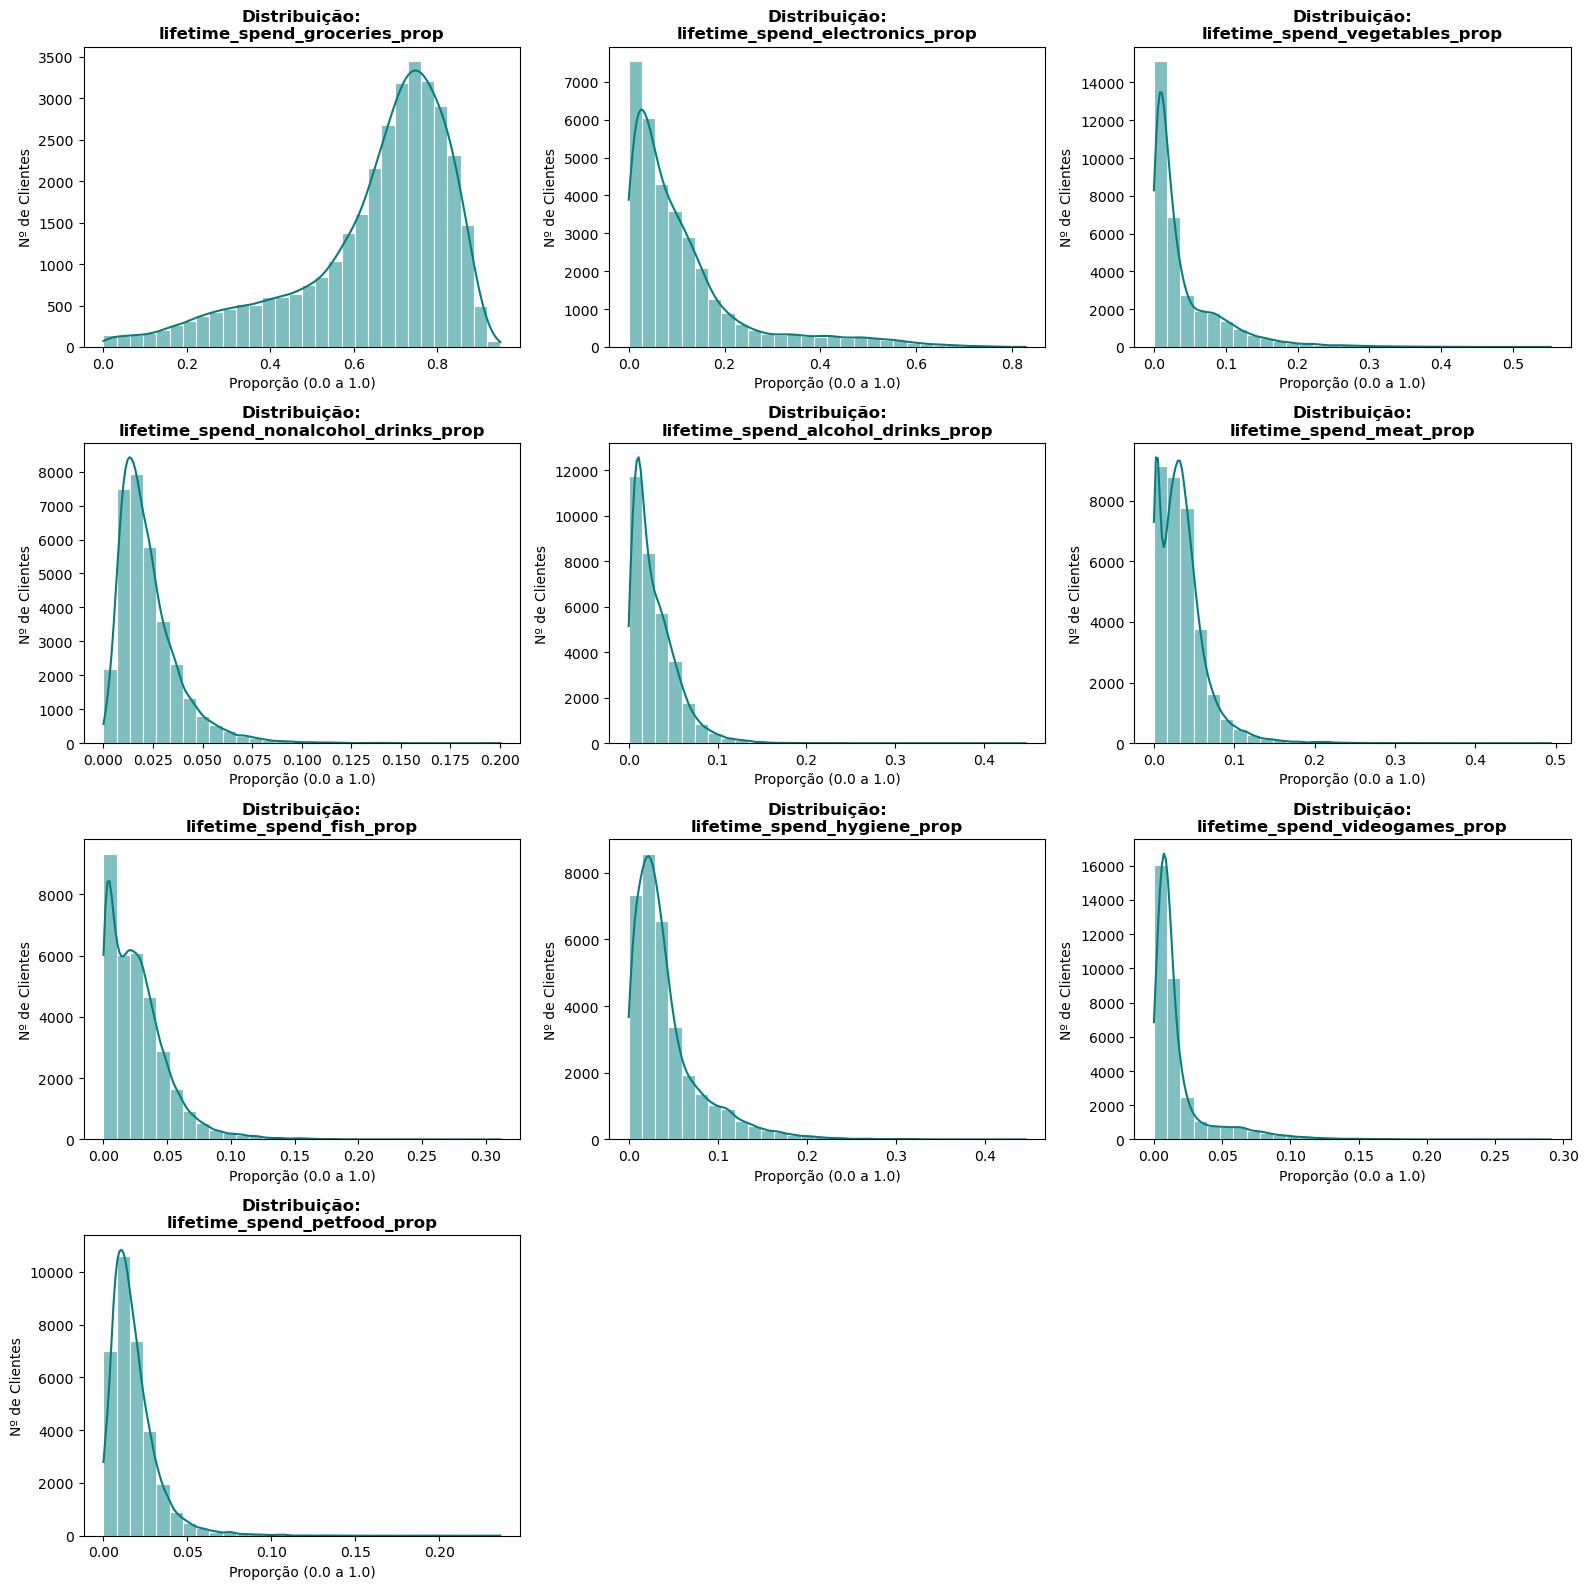

In [33]:
# Obter a lista das colunas de proporção que criámos
cols_proporcao = [col for col in data.columns if '_prop' in col]

# Preparar uma "grelha" para os gráficos (3 colunas, linhas dinâmicas)
num_cols = len(cols_proporcao)
linhas = int(np.ceil(num_cols / 3))
fig, axes = plt.subplots(nrows=linhas, ncols=3, figsize=(16, 4 * linhas))
axes = axes.flatten()

# Desenhar um histograma para cada variável
for i, col in enumerate(cols_proporcao):
    # O kde=True adiciona aquela linha de tendência curva para ver melhor a distribuição
    sns.histplot(data[col], bins=30, kde=True, ax=axes[i], color='teal', edgecolor='white')
    
    # Formatação do gráfico
    axes[i].set_title(f'Distribuição:\n{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Proporção (0.0 a 1.0)')
    axes[i].set_ylabel('Nº de Clientes')

# Remover eventuais gráficos vazios no fim da grelha (se o nº não for múltiplo de 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### Analysis of Relative Spend Skewness

Analyzing the distribution shape and skewness coefficients of the relative spending proportions yields key insights into customer purchasing patterns:

1. **Negative (Left) Skewness:**
   - **Groceries Proportion (`-1.2286`):** This is the only negatively skewed feature. The left-skewness indicates that for the vast majority of customers, groceries represent a major share of their household budget, pushing the bulk of the distribution to the right.

2. **Positive (Right) Skewness:**
   - **Discretionary / Special Interest Categories:** All other categories exhibit strong positive (right) skewness (ranging from `+1.91` to `+3.13`):
     - **Moderate Positive Skewness:** `fish_prop` (`1.9198`), `alcohol_drinks_prop` (`1.9412`), `nonalcohol_drinks_prop` (`2.0609`), and `electronics_prop` (`2.0822`).
     - **Highly Positive Skewness:** `hygiene_prop` (`2.2367`), `meat_prop` (`2.3577`), `vegetables_prop` (`2.4491`), `petfood_prop` (`2.7112`), and `videogames_prop` (`3.1341`).


The high right-skewness in specific categories (like videogames and petfood) highlights that the majority of customers spend very little or nothing on them, whereas a distinct niche of customers devotes a substantial portion of their wallet to these items. This makes these proportion features highly effective discriminators for identifying distinct customer personas (e.g., *Gamers*, *Pet Parents*, *Wellness/Vegan Buyers*).


# 1.7 Bivariate Analysis

## 1.7.1 Correlation Matrix

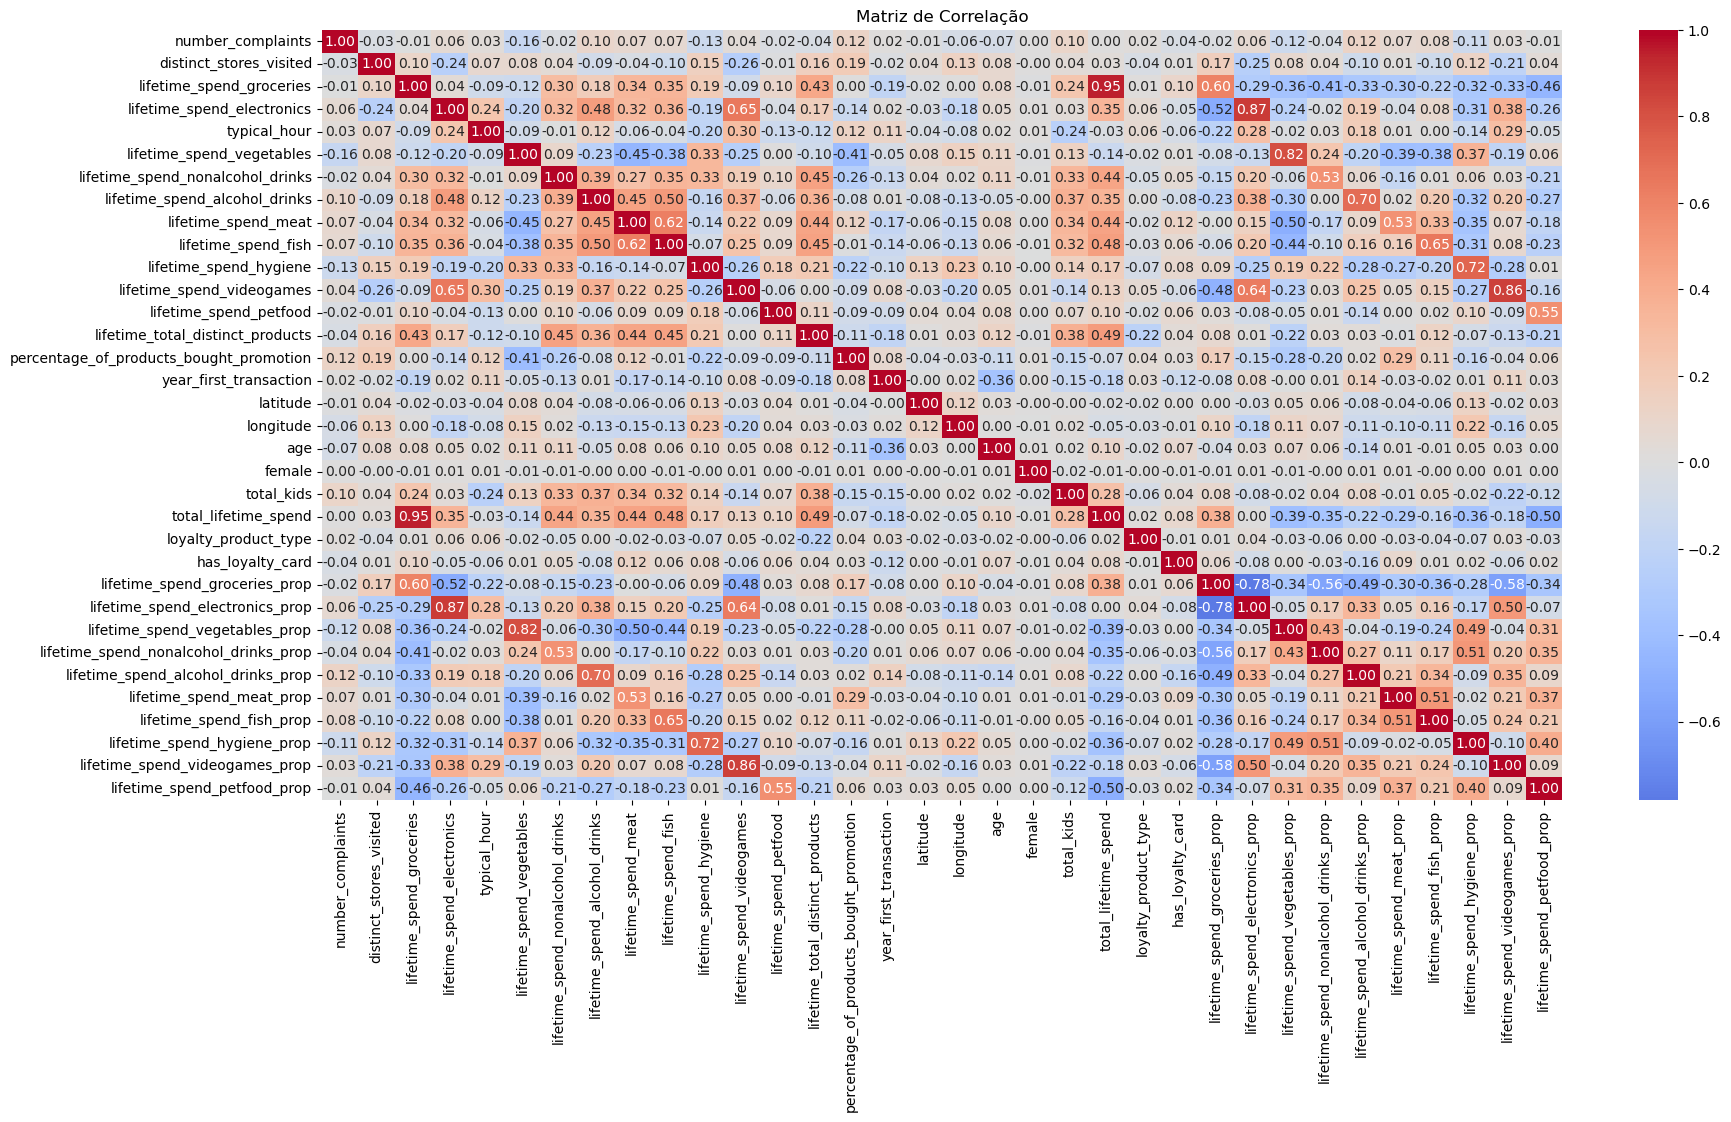

In [34]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
corr = data[numeric_cols].corr()

plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()



Most features are weakly correlated, but spending categories clearly move together. Customers who buy meat also tend to buy fish (~0.62), and heavy grocery spenders also spend more on videogames (~0.65). This suggests there are distinct spending profiles worth clustering around.

Family structure also shows up (kids and teens at home are moderately linked (~0.42)), and both show a slight negative pull on spending, meaning families tend to spend less freely across categories.

`customer_id` and `loyalty_card_number` are pure identifiers with no behavioural meaning, so they will be dropped. `birth_month` and `birth_day` are also likely to go since they carry no meaningful signal about customer behaviour, we compute `age` (in years) instead for modelling.


# 1.7 Final Insights

These insights summarize the customer profile, purchase behavior, and potential action areas based on the dataset.

- The dataset has 33,038 customers and strong engineered features such as age, total lifetime spend, average value per product, loyalty card ownership, and category spend proportions.
- Grocery spending dominates customer wallets; groceries account for the largest share of lifetime spend for most customers. This means promotions, loyalty rewards, and price sensitivity in the grocery category are key focus areas.
- Electronics is often the second-largest category by spend for higher-value customers, so cross-selling electronics and grocery items could increase basket value.
- Customers with higher lifetime spend also tend to buy a greater number of distinct products and visit more stores, so driving store engagement and product variety can support retention.
- A high percentage of products bought on promotion suggests a price-sensitive segment. Targeted promotional campaigns can help convert these shoppers into repeat customers.
- Loyalty card ownership is a strong signal for recurring behavior; customers with loyalty cards are likely more engaged and valuable.
- Household composition matters: customers with children or teenagers may have different purchasing priorities, especially in groceries, hygiene, and drink categories.
- Complaint counts are generally low, indicating stable satisfaction overall, but any cluster with repeated complaints should be examined for service improvement.
- Missing values in typical purchase hour and complaint counts should be cleaned or imputed before predictive modeling.
- The presence of latitude and longitude makes geographic segmentation possible; mapping customer spend and loyalty adoption by region can reveal location-based opportunities.
- Basket-level patterns show that many customers combine groceries with home and electronics items, making association rule mining useful for identifying relevant cross-category promotions.

Possible next steps:

- Use the engineered spend proportion features (`*_prop`) to segment customers by category preference independently of total spend.
- Analyze customer clusters by age, gender, loyalty card status, and promotional purchase ratio to define targeted retention and upsell strategies.
- Apply association rules on `customer_basket` data to identify high-value product combinations for bundling or recommendation.
- Explore geographic clusters and store visit patterns to align regional promotions and store placement.


Based on the exploratory data analysis conducted, the following preprocessing steps will be carried out before clustering.

We will start by **dropping identifier and low-signal features** — `customer_id`, `customer_name`, `loyalty_card_number`, `latitude` and `longitude`. The first three carry no behavioural meaning, while the remaining ones showed near-zero variance and no meaningful signal across the analysis. We will keep `age` (computed from `customer_birthdate`) for modelling.

`percentage_of_products_bought_promotion` presented negative values which are not interpretable and will need to be investigated and cleaned before proceeding.

All **spending features** are heavily right-skewed with significant outliers, so we will apply a **log transformation** followed by **outlier capping** to reduce the influence of extreme values on cluster centroids. After that, all features will be **standardized with StandardScaler** to ensure no single variable dominates due to scale differences.

Since several spending features are strongly correlated, we will apply **PCA** to reduce dimensionality and eliminate redundancy, retaining 90% of the variance. Finally, `customer_gender` will be **encoded** before being fed into the algorithm.

In [35]:
data

,customer_name,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,...,lifetime_spend_groceries_prop,lifetime_spend_electronics_prop,lifetime_spend_vegetables_prop,lifetime_spend_nonalcohol_drinks_prop,lifetime_spend_alcohol_drinks_prop,lifetime_spend_meat_prop,lifetime_spend_fish_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,...,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
4,Bsc. Glenda Bauman,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,...,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
5,Msc. Antonio Campbell,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,...,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
7,John Kelling,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,...,0.501137,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
8,Arthur Dematteo,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,...,0.356127,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,Joshua Howard,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,994.0,1020.0,...,0.023845,0.677108,0.009538,0.028765,0.049900,0.051205,0.057932,0.003112,0.080221,0.018373
39997,Anthony Hines,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,1417.0,1323.0,...,0.285569,0.488076,0.009858,0.016836,0.048001,0.044817,0.020393,0.007453,0.071308,0.007690
39998,Edna Hasselman,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,117.0,307.0,...,0.569715,0.105017,0.113532,0.035053,0.008302,0.021784,0.000000,0.121975,0.006315,0.018307


In [36]:
data.to_csv('customer_info_engineered.csv', index=False)